In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [3]:
clientes_df = pd.read_csv('clientes.csv')
pedidos_df = pd.read_csv('pedidos.csv')
entrega_df = pd.read_csv('entregas.csv')

In [4]:
clientes_df.head(5)

,id,nome,data_entrada,segmento,estado,cidade
0,1,Diego Nascimento,2024-03-30,Beleza,PB,Gomes
1,2,Cecília Campos,2024-06-07,Casa,PA,Lopes dos Dourados
2,3,Rafaela Souza,2024-10-06,Eletrônicos,MS,Moraes
3,4,Ana Lívia Sales,2024-09-03,Beleza,SC,Barbosa
4,5,Yuri Mendes,2024-10-25,Alimentos,AL,Ramos


In [5]:
pedidos_df.head(5)

,id,id_cliente,data_pedido,valor,canal_venda
0,1,57,2025-02-21,190.74,WhatsApp
1,2,156,2025-02-12,152.10,Marketplace
2,3,25,2025-03-11,1411.59,Marketplace
3,4,52,2024-12-17,328.56,WhatsApp
4,5,147,2024-12-07,122.34,Marketplace


In [6]:
entrega_df.head(5)

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou
1,2,Jadlog,Entregue,2025-02-20,2025-02-18,NaN
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha
3,4,Correios,Entregue,2024-12-17,2024-12-19,NaN
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha


Análise de clientes com problemas recorrentes de entrega

In [7]:
rel_entrega_pedido = entrega_df.merge(pedidos_df[['id', 'id_cliente']], left_on='id_pedido', right_on='id')
rel_entrega_pedido

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id,id_cliente
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57
1,2,Jadlog,Entregue,2025-02-20,2025-02-18,NaN,2,156
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25
3,4,Correios,Entregue,2024-12-17,2024-12-19,NaN,4,52
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147
...,...,...,...,...,...,...,...,...
995,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133
996,997,Total Express,Entregue,2024-10-10,2024-10-06,NaN,997,69
997,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120
998,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53


In [8]:
filtro_problemas = ['Atrasado','Extraviado','Devolvido']

pedidos_com_problemas = rel_entrega_pedido[rel_entrega_pedido['status'].isin(filtro_problemas)]
pedidos_com_problemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id,id_cliente
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147
6,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado,7,19
8,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha,9,110
...,...,...,...,...,...,...,...,...
994,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha,995,17
995,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133
997,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120
998,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53


Relação de NPS/recompras com cliente com problemas

In [9]:
clientes_com_problemas = pedidos_com_problemas.groupby('id_cliente').size().reset_index(name="qtd_problemas").sort_values(by='qtd_problemas',ascending=False)
clientes_com_problemas.head()

,id_cliente,qtd_problemas
137,186,7
13,17,5
74,103,4
2,6,4
149,198,4


In [10]:
nps_df = pd.read_csv('nps.csv')

In [11]:
nps_df

,id_cliente,data_resposta,nota,comentario
0,1,2024-06-29,9,Necessitatibus nulla sit expedita nostrum recu...
1,2,2024-06-13,10,Eaque ullam mollitia eaque earum ratione totam...
2,2,2025-03-16,8,Animi reiciendis commodi itaque quidem asperio...
3,3,2024-09-07,8,Voluptas ex ut esse.
4,3,2025-05-07,0,Porro expedita doloribus ullam ab adipisci eius.
...,...,...,...,...
384,198,2024-11-16,3,Debitis dolores optio officiis enim tenetur ip...
385,198,2024-11-04,9,Incidunt quisquam vitae unde aspernatur ad inc...
386,199,2024-06-21,1,Cupiditate placeat tenetur dicta atque occaeca...
387,200,2024-08-11,10,Maxime aspernatur dolore vero aut voluptate la...


In [12]:
rel_clientesProblemas_nps = clientes_com_problemas.merge(nps_df, on='id_cliente', how='left')
rel_clientesProblemas_nps

,id_cliente,qtd_problemas,data_resposta,nota,comentario
0,186,7,2024-10-02,10,Similique rem saepe ratione est eos nulla debi...
1,186,7,2024-10-05,8,Illum quibusdam recusandae praesentium optio f...
2,17,5,2024-08-10,4,Sunt iure exercitationem magni est nobis praes...
3,103,4,2024-11-05,0,Minima illo temporibus nemo possimus accusamus...
4,103,4,2024-09-06,6,Quo quos commodi occaecati ducimus fuga cum si...
...,...,...,...,...,...
295,61,1,2024-08-19,2,Nisi est consequuntur culpa.
296,61,1,2024-09-20,2,Iure maiores quibusdam tenetur corporis pariat...
297,61,1,2024-09-14,5,Dolores neque quasi asperiores tenetur.
298,3,1,2024-09-07,8,Voluptas ex ut esse.


In [13]:
def classificar_nps(nota):
    if nota >= 8:
        return "Bom"
    elif nota >= 5:
        return "Médio"
    else:
        return "Ruim"

In [14]:
rel_clientesProblemas_nps['classificacao'] = rel_clientesProblemas_nps['nota'].apply(classificar_nps)
rel_clientesProblemas_nps

,id_cliente,qtd_problemas,data_resposta,nota,comentario,classificacao
0,186,7,2024-10-02,10,Similique rem saepe ratione est eos nulla debi...,Bom
1,186,7,2024-10-05,8,Illum quibusdam recusandae praesentium optio f...,Bom
2,17,5,2024-08-10,4,Sunt iure exercitationem magni est nobis praes...,Ruim
3,103,4,2024-11-05,0,Minima illo temporibus nemo possimus accusamus...,Ruim
4,103,4,2024-09-06,6,Quo quos commodi occaecati ducimus fuga cum si...,Médio
...,...,...,...,...,...,...
295,61,1,2024-08-19,2,Nisi est consequuntur culpa.,Ruim
296,61,1,2024-09-20,2,Iure maiores quibusdam tenetur corporis pariat...,Ruim
297,61,1,2024-09-14,5,Dolores neque quasi asperiores tenetur.,Médio
298,3,1,2024-09-07,8,Voluptas ex ut esse.,Bom


In [15]:
rel_clientesProblemas_nps['classificacao'].value_counts()

classificacao
Ruim     133
Bom       93
Médio     74
Name: count, dtype: int64

In [16]:
pedidos_por_cliente = pedidos_df.groupby("id_cliente").size().reset_index(name="qtd_pedidos")
clientes_nps = rel_clientesProblemas_nps.merge(pedidos_por_cliente, on="id_cliente", how="left")
clientes_nps["fez_recompra"] = clientes_nps["qtd_pedidos"] > 1

clientes_nps["fez_recompra"].value_counts()

fez_recompra
True     296
False      4
Name: count, dtype: int64

Transportadoras mais associadas aos problemas

In [17]:
transportadoras_problemas = entrega_df['transportadora'][entrega_df['status'].isin(filtro_problemas)]
transportadoras_problemas.value_counts()

transportadora
Correios         78
Loggi            74
Total Express    68
Jadlog           60
Name: count, dtype: int64

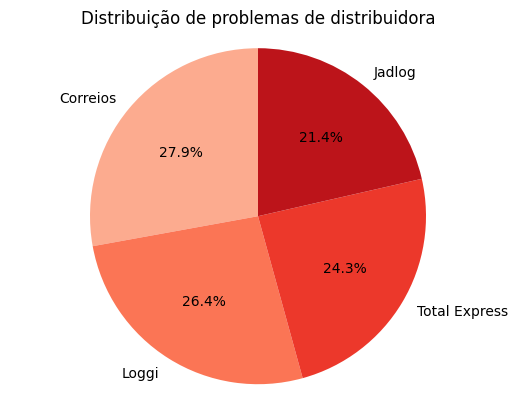

In [18]:
entrega_problema = entrega_df[entrega_df['status'].isin(filtro_problemas)]

dados_entrega = entrega_problema.groupby('transportadora').size().reset_index(name='qtd_problemas').sort_values(by='qtd_problemas', ascending=False)

plt.pie(dados_entrega['qtd_problemas'], labels=dados_entrega['transportadora'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Reds(np.linspace(0.3, 0.8, len(dados_entrega))))
plt.title('Distribuição de problemas de distribuidora')
plt.axis('equal')
plt.show()

Estados e segmentos com mais problemas

In [19]:
entregas_problemas = entrega_df[entrega_df['status'].isin(filtro_problemas)]
entregas_problemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou
2,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha
4,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha
6,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado
8,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha
...,...,...,...,...,...,...
994,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha
995,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou
997,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha
998,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado


In [20]:
rel_pedidos_entregaProblemas = entregas_problemas.merge(pedidos_df[['id','id_cliente']],left_on='id_pedido',right_on='id')
rel_pedidos_entregaProblemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id,id_cliente
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57
1,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25
2,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147
3,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado,7,19
4,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha,9,110
...,...,...,...,...,...,...,...,...
275,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha,995,17
276,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133
277,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120
278,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53


In [21]:
rel_cliente_entregaProblemas = rel_pedidos_entregaProblemas.merge(clientes_df[['id','estado','cidade','segmento']],left_on='id_cliente',right_on='id')
rel_cliente_entregaProblemas

,id_pedido,transportadora,status,data_entrega,prazo_estimado,motivo_ocorrencia,id_x,id_cliente,id_y,estado,cidade,segmento
0,1,Total Express,Devolvido,NaN,2025-02-28,Cliente recusou,1,57,57,RR,Fogaça,Alimentos
1,3,Correios,Atrasado,NaN,2025-03-20,Atraso na malha,3,25,25,SP,da Cruz,Moda
2,5,Jadlog,Atrasado,NaN,2024-12-13,Atraso na malha,5,147,147,MA,Mendes,Moda
3,7,Jadlog,Extraviado,NaN,2024-10-23,Extravio confirmado,7,19,19,RJ,Santos do Oeste,Alimentos
4,9,Loggi,Atrasado,NaN,2024-11-07,Atraso na malha,9,110,110,PI,Correia do Norte,Moda
...,...,...,...,...,...,...,...,...,...,...,...,...
275,995,Loggi,Atrasado,NaN,2024-10-25,Atraso na malha,995,17,17,PA,Cardoso do Sul,Alimentos
276,996,Jadlog,Devolvido,NaN,2024-08-06,Cliente recusou,996,133,133,RN,da Paz do Sul,Alimentos
277,998,Correios,Atrasado,NaN,2025-02-24,Atraso na malha,998,120,120,RN,da Costa Alegre,Alimentos
278,999,Loggi,Extraviado,NaN,2025-02-27,Extravio confirmado,999,53,53,RN,Araújo dos Dourados,Eletrônicos


In [22]:
problemas_Estado = rel_cliente_entregaProblemas.groupby('estado').size().reset_index(name='qtd_problemas').sort_values(by='qtd_problemas',ascending=False)
problemas_Estado

,estado,qtd_problemas
19,RN,33
4,BA,24
22,RS,17
13,PA,16
1,AL,16
3,AP,15
23,SC,15
11,MS,12
24,SE,11
5,CE,10


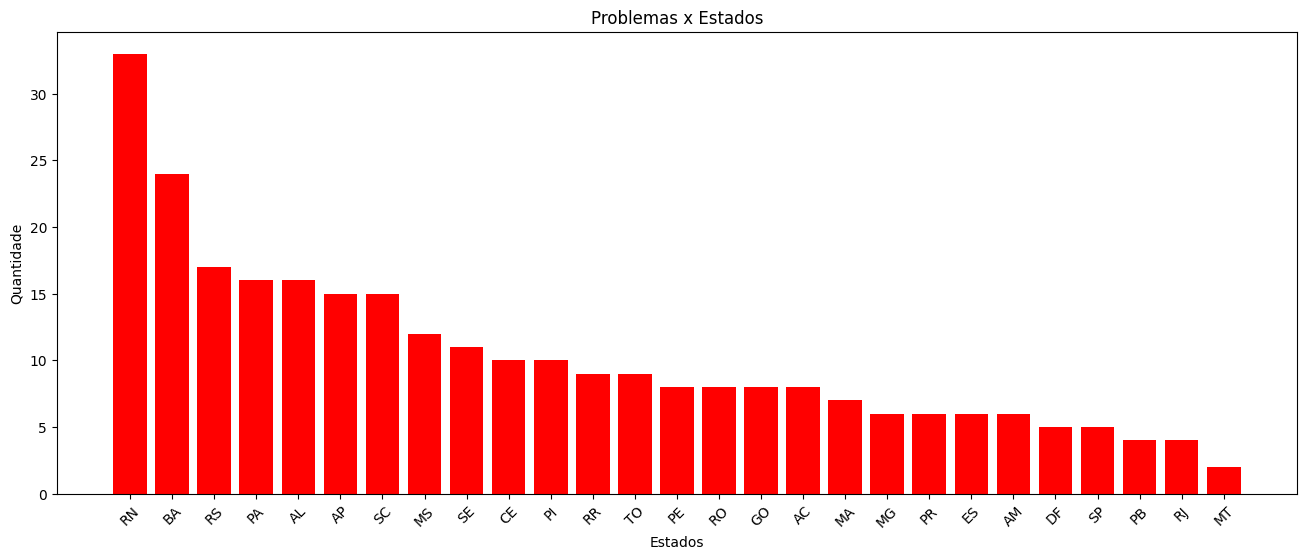

In [23]:
plt.figure(figsize=(16,6))
plt.bar(problemas_Estado['estado'], problemas_Estado['qtd_problemas'], color='r')
plt.xlabel('Estados')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.title("Problemas x Estados")
plt.show()

In [24]:
problemas_Segmento= rel_cliente_entregaProblemas.groupby('segmento').size().reset_index(name='qtd_problemas').sort_values(by='qtd_problemas',ascending=False)
problemas_Segmento

,segmento,qtd_problemas
0,Alimentos,72
3,Eletrônicos,72
2,Casa,47
1,Beleza,45
4,Moda,44


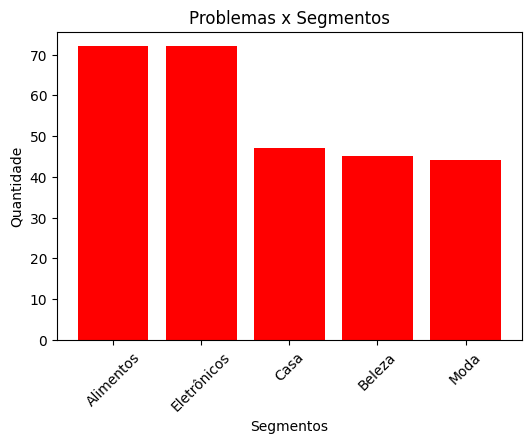

In [25]:
plt.figure(figsize=(6,4))
plt.bar(problemas_Segmento['segmento'], problemas_Segmento['qtd_problemas'], color='r')
plt.xlabel('Segmentos')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.title("Problemas x Segmentos")
plt.show()

Identifique as transportadoras com mais problemas por região.

In [26]:
filtro = rel_cliente_entregaProblemas.groupby(['estado','transportadora']).size().reset_index(name='qtd')
top_transp = filtro.groupby('estado')['qtd'].idxmax()
filtro.loc[top_transp]

,estado,transportadora,qtd
0,AC,Correios,3
3,AL,Correios,7
9,AM,Loggi,2
11,AP,Correios,6
17,BA,Loggi,10
22,CE,Total Express,4
23,DF,Correios,3
25,ES,Correios,2
30,GO,Jadlog,3
35,MA,Loggi,5


Liste os clientes com maior volume de problemas logísticos nos últimos 3 meses.

In [34]:

data_limite = datetime.now() - timedelta(days=90)

pedidos_df["data_pedido"] = pd.to_datetime(pedidos_df["data_pedido"], errors='coerce')
entrega_df["prazo_estimado"] = pd.to_datetime(entrega_df["prazo_estimado"], errors='coerce')
entrega_df["data_entrega"] = pd.to_datetime(entrega_df["data_entrega"], errors='coerce')

pedidos_3m = pedidos_df[pedidos_df["data_pedido"] >= data_limite]

entregas = entrega_df.rename(columns={"id_pedido": "id"})
entregas_pedidos = pedidos_3m.merge(entrega_df, on="id", how="inner")

problemas = entregas_pedidos[
    (entregas_pedidos["status"] != "Entregue") |
    (entregas_pedidos["motivo_ocorrencia"].notnull())
]

problemas_por_cliente = problemas.groupby("id_cliente").size().reset_index(name="quantidade_problemas")

resultado = problemas_por_cliente.merge(clientes, left_on="id_cliente", right_on="id")

resultado = resultado[["nome", "quantidade_problemas"]].sort_values(by="quantidade_problemas", ascending=False)

resultado.head(10)


,nome,quantidade_problemas
0,Pietro da Luz,2
13,Ana Clara Freitas,2
37,Carlos Eduardo Barbosa,2
32,Bruno Cunha,2
38,Lucas Gabriel Vieira,2
29,Enzo Gabriel Pires,2
42,Sra. Lívia Pinto,2
47,Dra. Sophia Moraes,2
49,Dra. Maria Vitória Lopes,2
35,Gabrielly Ramos,2


Recompra ou abandono de clientes com problemas

In [35]:
problemas = entrega_df[entrega_df['status'].isin(['Atrasado','Devolvido'])]
pedidos_com_problemas = pedidos_df.merge(problemas, left_on='id', right_on='id_pedido')

In [45]:
problemas_por_cliente = pedidos_com_problemas.loc[:, ["id_cliente", "data_pedido"]].copy()
problemas_por_cliente["data_pedido"] = pd.to_datetime(problemas_por_cliente["data_pedido"])

In [58]:
pedidos_df['data_pedido'] = pd.to_datetime(pedidos_df['data_pedido'])
recompras = []

Total de clientes com problemas: 139
Clientes que recompraram: 105 (75.54%)
Clientes que abandonaram: 34 (24.46%)


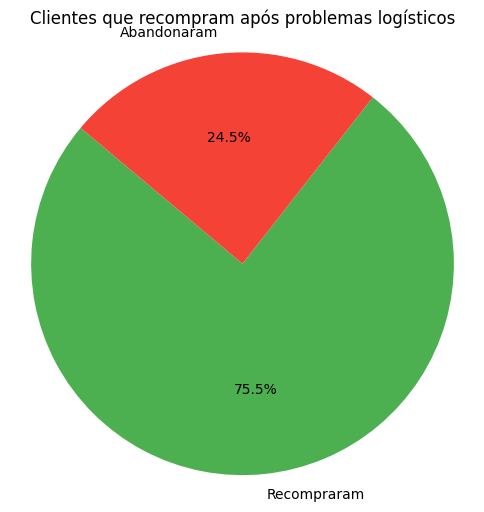

In [59]:
for _, row, in problemas_por_cliente.iterrows():
    id_cliente = row['id_cliente']
    data_problema = row['data_pedido']
    pedidos_futuros = pedidos_df[(pedidos_df['id_cliente'] == id_cliente) & (pedidos_df['data_pedido'] > data_problema)]
    recompras.append({
        'id_cliente':id_cliente,
        'recompra':not pedidos_futuros.empty
    })
recompras = pd.DataFrame(recompras).drop_duplicates("id_cliente")
total = recompras.shape[0]
recompras = recompras["recompra"].sum()
abandono = total - recompras

print(f"Total de clientes com problemas: {total}")
print(f"Clientes que recompraram: {recompras} ({(recompras / total) * 100:.2f}%)")
print(f"Clientes que abandonaram: {abandono} ({(abandono / total) * 100:.2f}%)")

label = ['Recompraram', 'Abandonaram']
valores = [recompras, abandono]
cores = ['#4CAF50', '#F44336']

plt.figure(figsize=(6,6))
plt.pie(valores, labels = label, autopct = '%1.1f%%', colors= cores, startangle=140)
plt.title("Clientes que recompram após problemas logísticos")
plt.axis('equal')
plt.show()

Verifique a correlação entre problemas logísticos e o NPS.

In [60]:
pedidos_df['data_pedido'] = pd.to_datetime(pedidos_df['data_pedido'])

In [64]:
problemas_df = entrega_df[entrega_df['status'].isin(['Atrasado','Devolvido'])]
pedidos_com_problema = pedidos_df.merge(problemas_df, left_on='id', right_on='id_pedido')
clientes_com_problemas = pedidos_com_problema['id_cliente'].unique()
clientes_com_problemas


array([ 57,  25, 147, 110,  32, 131, 153,  71, 161, 200, 138, 148, 195,
        70, 181, 155, 107,  93,  35, 149,  29,  75,  23,  15,  92, 142,
       183, 168, 182, 186,  38, 196, 151, 112,  80, 103, 184,  26, 108,
        27,  74,  37, 122, 115,  58,  11,  36, 105,  55,  63, 192,  89,
        12,  42,  54, 119, 100,  81,  53,  13, 163, 130,   6,  39, 156,
        62,  67, 165, 111, 164, 152, 172, 106, 188, 143, 176, 173, 198,
        60,   7, 193, 187, 171,  83,  17,  28,  44,  76,  79,   8, 137,
       123,  10, 178,   3, 146, 170,  18, 135, 133, 120,  16, 157, 114,
       191,  45,  73,  31,  21, 136,  87, 113,  78,  47,  77, 159, 162,
       134,  61,  95, 197, 175, 169, 194, 189,  19,  96, 150, 116,   9,
        65,  46, 118, 160, 158, 144,   5, 124, 190])

In [65]:
nps_df['teve_problema_logistico'] = nps_df['id_cliente'].isin(clientes_com_problemas)

In [68]:
correlacao = nps_df['teve_problema_logistico'].astype(int).corr(nps_df['nota'])
correlacao

np.float64(-0.040803153540771596)

In [69]:
media_com_problema = nps_df[nps_df['teve_problema_logistico'] == True]['nota'].mean()
media_sem_problema = nps_df[nps_df['teve_problema_logistico'] == False]['nota'].mean()

In [70]:
print(f"Correlação entre problemas logísticos e NPS: {correlacao:.2f}")
print(f"Média de NPS com problema logístico: {media_com_problema:.2f}")
print(f"Média de NPS sem problema logístico: {media_sem_problema:.2f}")

Correlação entre problemas logísticos e NPS: -0.04
Média de NPS com problema logístico: 5.11
Média de NPS sem problema logístico: 5.39


In [96]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

In [85]:
nps_df['classificacao'] = nps_df['nota'].apply(classificar_nps)
nps_df = nps_df.drop(['id_cliente','data_resposta','nota'], axis=1)


In [86]:
nps_df

,comentario,classificacao
0,Necessitatibus nulla sit expedita nostrum recu...,Bom
1,Eaque ullam mollitia eaque earum ratione totam...,Bom
2,Animi reiciendis commodi itaque quidem asperio...,Bom
3,Voluptas ex ut esse.,Bom
4,Porro expedita doloribus ullam ab adipisci eius.,Ruim
...,...,...
384,Debitis dolores optio officiis enim tenetur ip...,Ruim
385,Incidunt quisquam vitae unde aspernatur ad inc...,Bom
386,Cupiditate placeat tenetur dicta atque occaeca...,Ruim
387,Maxime aspernatur dolore vero aut voluptate la...,Bom


In [93]:
encoder = LabelEncoder()
nps_df['classificacao_cod'] = encoder.fit_transform(nps_df['classificacao'])

In [94]:
nps_df

,comentario,classificacao,classificacao_cod
0,Necessitatibus nulla sit expedita nostrum recu...,Bom,0
1,Eaque ullam mollitia eaque earum ratione totam...,Bom,0
2,Animi reiciendis commodi itaque quidem asperio...,Bom,0
3,Voluptas ex ut esse.,Bom,0
4,Porro expedita doloribus ullam ab adipisci eius.,Ruim,2
...,...,...,...
384,Debitis dolores optio officiis enim tenetur ip...,Ruim,2
385,Incidunt quisquam vitae unde aspernatur ad inc...,Bom,0
386,Cupiditate placeat tenetur dicta atque occaeca...,Ruim,2
387,Maxime aspernatur dolore vero aut voluptate la...,Bom,0


In [95]:
x = nps_df['comentario']
y = nps_df['classificacao_cod']

In [97]:
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(x)

In [101]:
vectorizer.get_feature_names_out()

array(['ab', 'accusamus', 'accusantium', 'ad', 'adipisci', 'alias',
       'aliquam', 'aliquid', 'amet', 'animi', 'aperiam', 'architecto',
       'asperiores', 'aspernatur', 'assumenda', 'at', 'atque', 'aut',
       'autem', 'beatae', 'blanditiis', 'commodi', 'consectetur',
       'consequatur', 'consequuntur', 'corporis', 'corrupti', 'culpa',
       'cum', 'cumque', 'cupiditate', 'debitis', 'delectus', 'deleniti',
       'deserunt', 'dicta', 'dignissimos', 'distinctio', 'dolor',
       'dolore', 'dolorem', 'doloremque', 'dolores', 'doloribus',
       'dolorum', 'ducimus', 'ea', 'eaque', 'earum', 'eius', 'eligendi',
       'enim', 'eos', 'error', 'esse', 'est', 'et', 'eum', 'eveniet',
       'ex', 'excepturi', 'exercitationem', 'expedita', 'explicabo',
       'facere', 'facilis', 'fuga', 'fugiat', 'fugit', 'harum', 'hic',
       'id', 'illo', 'illum', 'impedit', 'in', 'incidunt', 'inventore',
       'ipsa', 'ipsam', 'ipsum', 'iste', 'itaque', 'iure', 'iusto',
       'labore', 'laborios

In [102]:
nps_df = nps_df.drop(['classificacao'],axis=1)

In [104]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=5)

In [106]:
x_train.shape

(311, 181)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(400, input_shape=(311,), activation='relu'),
    tf.keras.layers.Dense(400, activation='relu'),
    tf.keras.layers.Dense(400, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

C:\Users\antonioso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [110]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x,y, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 1), output.shape=(None, 3)